Making py-feat work on Colab with Python 3.11:

In [1]:
!pip install -qqq --use-deprecated=legacy-resolver py-feat librosa matplotlib "numpy<2" "scipy<1.14"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 73.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 26.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.5/383.5 kB 32.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 32.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 76.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 140.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 70.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import librosa.display
from feat import Detector
import pandas as pd

detector = Detector(face_model="retinaface", au_model="xgb", device="cuda")

print("Step 1: Extracting Facial Action Units (this may take a minute)...")
video_prediction = detector.detect_video("stuttering_example.mp4", skip_frames=1)

In [ ]:
# Py-Feat labels AUs as 'AU01', 'AU06', etc.
# It provides intensity/probability scores.
results_df = video_prediction.aus

results_df.head()

Step 2: Processing Audio...


/tmp/ipython-input-35-455708049.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load("stuttering_example.mp4")
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


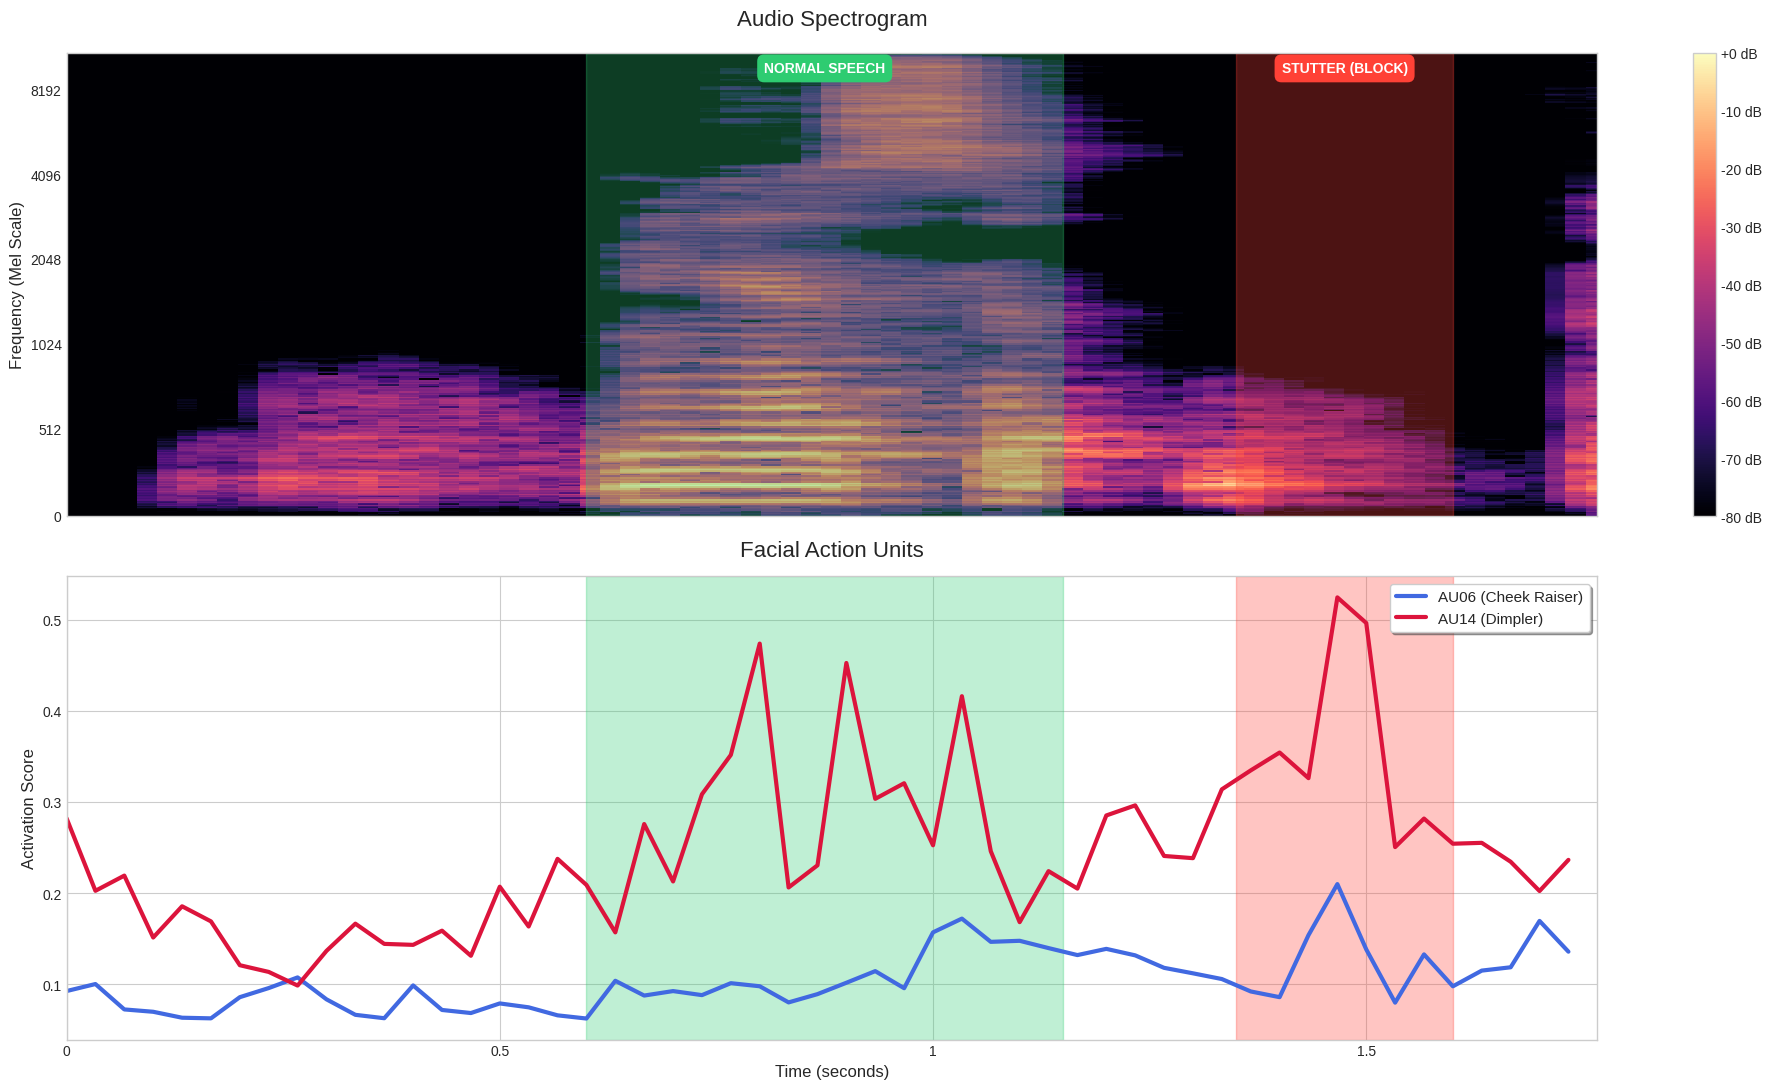

In [35]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

stutter_interval = [1.35, 1.6]
normal_interval = [0.6, 1.15]

# 2. Extract Audio and Spectrogram
print("Step 2: Processing Audio...")
y, sr = librosa.load("stuttering_example.mp4")
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=512)
S_dB = librosa.power_to_db(S, ref=np.max)

# 3. Alignment
fps = 30
time_au = np.arange(len(results_df)) / fps

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 11), sharex=True)

# --- 1. SPECTROGRAM (Top) ---
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=ax1, cmap='magma')

ax1.set_title('Audio Spectrogram', fontsize=16, pad=20)
ax1.set_ylabel('Frequency (Mel Scale)', fontsize=12)

cbar = fig.colorbar(img, ax=ax1, format='%+2.0f dB')

# --- 2. FACIAL ACTION UNITS (Bottom) ---
ax2.plot(time_au, results_df['AU06'], label='AU06 (Cheek Raiser)', color='#4169E1', linewidth=3)
ax2.plot(time_au, results_df['AU14'], label='AU14 (Dimpler)', color='#DC143C', linewidth=3)

ax2.set_ylabel('Activation Score', fontsize=12)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_title('Facial Action Units', fontsize=16, pad=15)
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
# ax2.set_ylim(0, results_df[['AU06', 'AU14']].values.max() + 0.1)

# --- 3. SYNCED HIGHLIGHTS & LABELS ---
green_hex = '#2ECC71'
red_hex = '#FF4136'

for ax in [ax1, ax2]:
    ax.axvspan(normal_interval[0], normal_interval[1], color=green_hex, alpha=0.3)
    ax.axvspan(stutter_interval[0], stutter_interval[1], color=red_hex, alpha=0.3)

label_y = ax1.get_ylim()[1] * 0.88

ax1.text(np.mean(normal_interval), label_y, 'NORMAL SPEECH',
         color='white', weight='bold', ha='center', va='center',
         bbox=dict(facecolor=green_hex, edgecolor='none', boxstyle='round,pad=0.5'))

ax1.text(np.mean(stutter_interval), label_y, 'STUTTER (BLOCK)',
         color='white', weight='bold', ha='center', va='center',
         bbox=dict(facecolor=red_hex, edgecolor='none', boxstyle='round,pad=0.5'))

# Clean up
ax1.set_xlabel('')
ax1.grid(False)
ax2.set_xlim(time_au[0], time_au[-1])

plt.tight_layout()

pos = ax1.get_position()
pos2 = ax2.get_position()
ax2.set_position([pos.x0,pos2.y0,pos.width,pos2.height])

plt.savefig("example.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()